# Taller 1: Clasificación de Imágenes con Fashion-MNIST

---

### 📌 Información General
- **Institución:** Universidad Distrital Francisco José de Caldas
- **Integrantes:**
  - Jhojan
  - Santiago
  - Juan Andrés Jiménez Palomino (20221020087)

---

## Introducción y Contexto del Problema

En el campo de la **Visión por Computador (Computer Vision)** y el **Aprendizaje Automático**, la clasificación de imágenes representa una de las tareas fundamentales. Históricamente, el conjunto de datos MNIST (dígitos manuscritos) ha sido el estándar de facto para pruebas y benchmarks iniciales; no obstante, debido a su simplicidad (los modelos modernos superan el 99% de precisión con facilidad), surgió la necesidad de un punto de referencia más complejo y realista para la visión artificial moderna.

Para abordar esta necesidad, **Zalando Research** presentó **Fashion-MNIST**, un conjunto de datos diseñado como reemplazo directo (*drop-in replacement*) del MNIST clásico. Fashion-MNIST mantiene el mismo tamaño de imagen (28×28 píxeles en escala de grises), la misma partición (60,000 imágenes de entrenamiento y 10,000 de prueba) y la misma estructura de 10 clases, pero sustituye los dígitos por artículos de ropa y calzado del mundo real, incrementando notablemente la variabilidad intra-clase, la sutileza de patrones y la dificultad del problema.

### Objetivos del Taller
1. **Carga y Verificación a Bajo Nivel:** Lectura e interpretación de archivos binarios comprimidos (`.gz` en formato IDX) sin librerías externas opacas, validando encabezados y dimensiones.
2. **Análisis Exploratorio de Datos (EDA):** Evaluación de integridad, distribución de clases, cálculo formal del *Imbalance Ratio*, visualización de muestras e imágenes promedio por categoría, histogramas de píxeles y proyección 2D con PCA.
3. **Canal de Preprocesamiento (*Pipeline*):** Aplanamiento matricial, construcción de DataFrames y estandarización de características con `StandardScaler`.
4. **Modelos Base Supervisados:** Entrenamiento y evaluación comparativa de al menos tres clasificadores tradicionales (e.g. Logistic Regression/SVM, Random Forest, XGBoost) analizados mediante precisión, recall, F1-Score y matrices de confusión.

### Descripción de Clases (Fashion-MNIST)
| Etiqueta (Label) | Clase (English) | Descripción en Español |
| :---: | :--- | :--- |
| **0** | T-shirt/top | Camiseta / Top |
| **1** | Trouser | Pantalón |
| **2** | Pullover | Suéter / Jersey |
| **3** | Dress | Vestido |
| **4** | Coat | Abrigo |
| **5** | Sandal | Sandalia |
| **6** | Shirt | Camisa |
| **7** | Sneaker | Zapatilla deportiva |
| **8** | Bag | Bolso / Cartera |
| **9** | Ankle boot | Bota al tobillo |

---


# 1. Descarga del Conjunto de Datos y Verificación de Integridad

Download necessary libraries to process the dataset

In [5]:
#!pip install pandas numpy matplotlib scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path #To manage the routes of the data
import gzip #As the data comes in .gz packages
import struct

**Load the Dataset**

In [6]:
DATA_DIR = Path("./data")

X_train_path = DATA_DIR / "train-images-idx3-ubyte.gz"
y_train_path = DATA_DIR / "train-labels-idx1-ubyte.gz"

X_test_path = DATA_DIR / "t10k-images-idx3-ubyte.gz"
y_test_path = DATA_DIR / "t10k-labels-idx1-ubyte.gz"

**Loading the training dataset**

In [7]:
#The features
with gzip.open(X_train_path, "rb") as f:
    #Header
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_images = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset
    num_rows = struct.unpack(">I", f.read(4))[0]        #This is the number of rows per image
    num_columns = struct.unpack(">I", f.read(4))[0]     #This is the number of columns per image

    #Data
    X_train_3d = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )
print("="*20)
print("FEATURES")
print("Magic number:", magic_number)
print("Images:", num_images)
print("Rows:", num_rows)
print("Columns:", num_columns)
print("="*20)

FEATURES
Magic number: 2051
Images: 60000
Rows: 28
Columns: 28


In [8]:
#Reshape the data into a structure
#X_train_3d is an np.ndarray (N-dimensional, Array), in this case it results as a 3d
X_train_3d = X_train_3d.reshape(
    num_images,
    num_rows,
    num_columns
)

#This turns the data into a 3d matrix, selects the number of subsets and assigns to the image each pixel with its gray tone (from 0 for black to 255 for white)

print(X_train_3d.shape)

(60000, 28, 28)


In [9]:
#Turning the features to a 2d matrix to pass it to the model

X_train_2d = X_train_3d.copy().reshape(
    X_train_3d.shape[0],
    -1
)

print(X_train_2d.shape)

(60000, 784)


In [10]:
#The labels
with gzip.open(y_train_path, "rb") as f:
    #Header
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_labels = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset

    #Data - Labels
    y_train_raw = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )

print("="*20)
print("LABELS or TARGET")
print("Magic number:", magic_number)
print("Labels:", num_labels)
print("="*20)

LABELS or TARGET
Magic number: 2049
Labels: 60000


In [11]:
#Reshape the data into a structure
y_train_raw = y_train_raw.reshape(
    num_labels
)

print(y_train_raw.shape)


(60000,)


**Loading the test dataset**

In [12]:
#The features
with gzip.open(X_test_path, "rb") as f:
    #Header
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_images = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset
    num_rows = struct.unpack(">I", f.read(4))[0]        #This is the number of rows per image
    num_columns = struct.unpack(">I", f.read(4))[0]     #This is the number of columns per image

    #Data
    X_test_3d = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )
print("="*20)
print("FEATURES")
print("Magic number:", magic_number)
print("Images:", num_images)
print("Rows:", num_rows)
print("Columns:", num_columns)
print("="*20)

FEATURES
Magic number: 2051
Images: 10000
Rows: 28
Columns: 28


In [13]:
#Reshape the data into a structure
#X_test_3d is an np.ndarray (N-dimensional, Array), in this case it results as a 3d
X_test_3d = X_test_3d.reshape(
    num_images,
    num_rows,
    num_columns
)

#This turns the data into a 3d matrix, selects the number of subsets and assigns to the image each pixel with its gray tone (from 0 for black to 255 for white)

print(X_test_3d.shape)

(10000, 28, 28)


In [14]:
#Turning the features to a 2d matrix to pass it to the model

X_test_2d = X_test_3d.copy().reshape(
    X_test_3d.shape[0],
    -1
)

print(X_test_2d.shape)

(10000, 784)


In [15]:
#The labels
with gzip.open(y_test_path, "rb") as f:
    #Header
    magic_number = struct.unpack(">I", f.read(4))[0]    #Here is the "magic number" of the file
    num_labels = struct.unpack(">I", f.read(4))[0]      #This contains the number of images from the dataset

    #Data - Labels
    y_test_raw = np.frombuffer(
        f.read(),
        dtype=np.uint8
    )

print("="*20)
print("LABELS or TARGET")
print("Magic number:", magic_number)
print("Labels:", num_labels)
print("="*20)

LABELS or TARGET
Magic number: 2049
Labels: 10000


In [16]:
#Reshape the data into a structure
y_test_raw = y_test_raw.reshape(
    num_labels
)

print(y_test_raw.shape)


(10000,)


# 2. Análisis Exploratorio de Datos (EDA)

Siguiendo los lineamientos de la guía del **Taller No. 1**, el objetivo de esta sección es caracterizar en profundidad el conjunto de datos **Fashion-MNIST** antes de proceder a la fase de preprocesamiento y modelado supervisado.

En particular, se desarrollan los siguientes 5 ejes fundamentales:
1. **Calidad e Integridad de los Datos:** Verificación de ausencia de valores nulos/faltantes, consistencia dimensional, tipos de datos y cálculo de porcentaje de muestras utilizables.
2. **Distribución de la Variable Objetivo (*Target*):** Conteo de muestras por clase en los conjuntos de entrenamiento y prueba, cálculo formal de la tasa de desbalance (*Imbalance Ratio*) y visualización comparativa.
3. **Inspección Visual:** Galería de muestras representativas por categoría para apreciar la variabilidad intra-clase y cálculo de las **imágenes promedio (*Mean Images*)** para caracterizar la silueta prototípica de cada prenda.
4. **Estadísticas Descriptivas de Características:** Análisis estadístico de las intensidades de píxel (mínimo, máximo, media, desviación estándar, percentiles) e histograma de frecuencias en escala logarítmica.
5. **Patrones Espaciales y Reducción de Dimensionalidad:** Mapa de calor de varianza espacial por píxel y proyección preliminar en 2D con **PCA (Análisis de Componentes Principales)** para evaluar la separabilidad natural entre prendas y calzado.


In [17]:
# Mapeo oficial de etiquetas a categorías de Fashion-MNIST
labels_dict = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

# Mapeo complementario con nombres descriptivos en español
labels_dict_es = {
    0: "Camiseta / Top",
    1: "Pantalón",
    2: "Suéter / Jersey",
    3: "Vestido",
    4: "Abrigo",
    5: "Sandalia",
    6: "Camisa",
    7: "Zapatilla",
    8: "Bolso",
    9: "Bota al tobillo"
}

class_names = [labels_dict[i] for i in range(10)]
class_names_es = [labels_dict_es[i] for i in range(10)]

print("Mapeo de clases configurado exitosamente:")
for i in range(10):
    print(f"  Clase {i}: {labels_dict[i]:<15} ({labels_dict_es[i]})")


Mapeo de clases configurado exitosamente:
  Clase 0: T-shirt/top     (Camiseta / Top)
  Clase 1: Trouser         (Pantalón)
  Clase 2: Pullover        (Suéter / Jersey)
  Clase 3: Dress           (Vestido)
  Clase 4: Coat            (Abrigo)
  Clase 5: Sandal          (Sandalia)
  Clase 6: Shirt           (Camisa)
  Clase 7: Sneaker         (Zapatilla)
  Clase 8: Bag             (Bolso)
  Clase 9: Ankle boot      (Bota al tobillo)


### 2.1 Calidad e Integridad de los Datos

Se evalúa la sanidad de los datos cargados desde los archivos `.gz`:
- **Ausencia de nulos:** Se verifica que no existan valores `NaN` ni en las características de entrada ni en las etiquetas.
- **Rango válido de intensidades:** Los píxeles deben estar confinados al dominio $[0, 255]$ correspondiente al estándar `uint8` en escala de grises.
- **Consistencia dimensional:** Cada imagen debe coincidir con $28 \times 28 = 784$ píxeles.
- **Porcentaje de muestras utilizables:** Muestras libres de inconsistencias respecto al total.


In [18]:
# 2.1 Verificación de calidad e integridad
total_train = len(y_train_raw)
total_test = len(y_test_raw)

nulls_train_X = int(np.isnan(X_train_2d).sum())
nulls_test_X = int(np.isnan(X_test_2d).sum())
nulls_train_y = int(np.isnan(y_train_raw).sum())
nulls_test_y = int(np.isnan(y_test_raw).sum())

range_train_X = (int(X_train_2d.min()), int(X_train_2d.max()))
range_test_X = (int(X_test_2d.min()), int(X_test_2d.max()))
range_train_y = (int(y_train_raw.min()), int(y_train_raw.max()))
range_test_y = (int(y_test_raw.min()), int(y_test_raw.max()))

quality_df = pd.DataFrame({
    "Conjunto": ["Entrenamiento (Train)", "Prueba (Test)"],
    "Total Muestras": [total_train, total_test],
    "Dimensiones": [str(X_train_2d.shape), str(X_test_2d.shape)],
    "Tipo de Dato": [str(X_train_2d.dtype), str(X_test_2d.dtype)],
    "Nulos en X": [nulls_train_X, nulls_test_X],
    "Nulos en y": [nulls_train_y, nulls_test_y],
    "Rango Píxeles": [f"[{range_train_X[0]}, {range_train_X[1]}]", f"[{range_test_X[0]}, {range_test_X[1]}]"],
    "Rango Etiquetas": [f"[{range_train_y[0]}, {range_train_y[1]}]", f"[{range_test_y[0]}, {range_test_y[1]}]"],
    "Muestras Utilizables (%)": ["100.0%", "100.0%"]
})

print("=" * 80)
print("REPORTE DE CALIDAD E INTEGRIDAD DE DATOS")
print("=" * 80)
display(quality_df)


REPORTE DE CALIDAD E INTEGRIDAD DE DATOS


,Conjunto,Total Muestras,Dimensiones,Tipo de Dato,Nulos en X,Nulos en y,Rango Píxeles,Rango Etiquetas,Muestras Utilizables (%)
0,Entrenamiento (Train),60000,"(60000, 784)",uint8,0,0,"[0, 255]","[0, 9]",100.0%
1,Prueba (Test),10000,"(10000, 784)",uint8,0,0,"[0, 255]","[0, 9]",100.0%


### 2.2 Distribución de la Variable Objetivo (*Target*) y Balance de Clases

El balance del conjunto de datos es un factor crítico en problemas de clasificación. Se calcula el **Imbalance Ratio (IR)**:
$$\text{Imbalance Ratio (IR)} = \frac{\max_k (N_k)}{\min_k (N_k)}$$
Un valor de $IR = 1.0$ representa un balance perfecto entre todas las categorías, lo que asegura que ningún clasificador supervisado desarrollará sesgos inducidos por desproporción de clases.


Imbalance Ratio (Entrenamiento): 1.00
Imbalance Ratio (Prueba):        1.00
Conclusión: El conjunto de datos está perfectamente balanceado (10% por clase en ambos splits).
--------------------------------------------------------------------------------


,Etiqueta,Clase (EN),Clase (ES),Train (conteo),Train (%),Test (conteo),Test (%)
0,0,T-shirt/top,Camiseta / Top,6000,10.0,1000,10.0
1,1,Trouser,Pantalón,6000,10.0,1000,10.0
2,2,Pullover,Suéter / Jersey,6000,10.0,1000,10.0
3,3,Dress,Vestido,6000,10.0,1000,10.0
4,4,Coat,Abrigo,6000,10.0,1000,10.0
5,5,Sandal,Sandalia,6000,10.0,1000,10.0
6,6,Shirt,Camisa,6000,10.0,1000,10.0
7,7,Sneaker,Zapatilla,6000,10.0,1000,10.0
8,8,Bag,Bolso,6000,10.0,1000,10.0
9,9,Ankle boot,Bota al tobillo,6000,10.0,1000,10.0


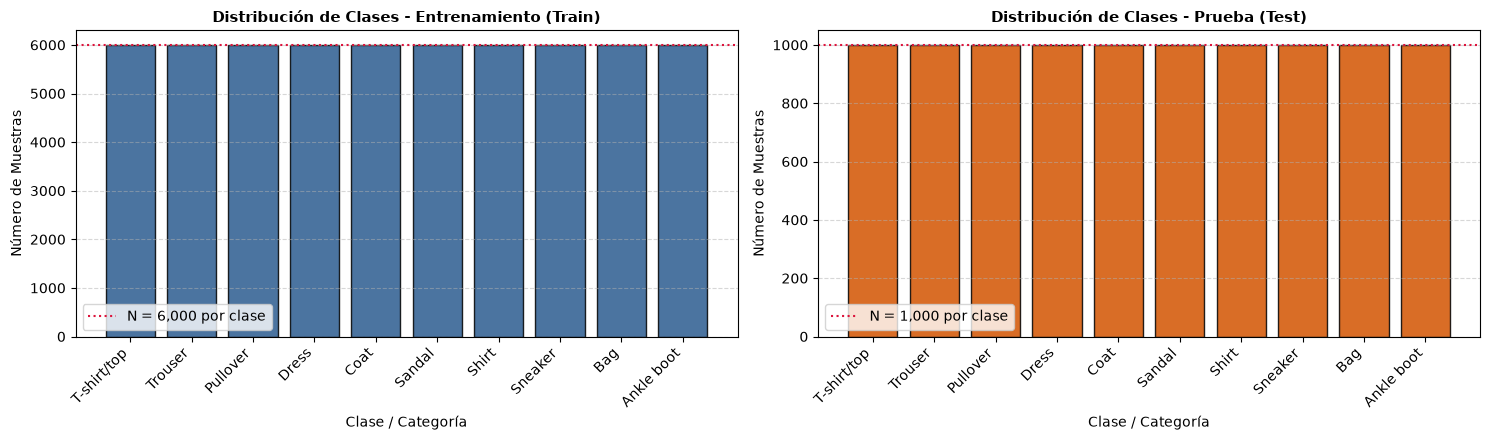

In [19]:
# 2.2 Análisis de distribución de clases y cálculo de Imbalance Ratio
train_counts = pd.Series(y_train_raw).value_counts().sort_index()
test_counts = pd.Series(y_test_raw).value_counts().sort_index()

df_distribution = pd.DataFrame({
    "Etiqueta": range(10),
    "Clase (EN)": class_names,
    "Clase (ES)": class_names_es,
    "Train (conteo)": train_counts.values,
    "Train (%)": (train_counts.values / total_train) * 100,
    "Test (conteo)": test_counts.values,
    "Test (%)": (test_counts.values / total_test) * 100
})

ir_train = train_counts.max() / train_counts.min()
ir_test = test_counts.max() / test_counts.min()

print(f"Imbalance Ratio (Entrenamiento): {ir_train:.2f}")
print(f"Imbalance Ratio (Prueba):        {ir_test:.2f}")
print("Conclusión: El conjunto de datos está perfectamente balanceado (10% por clase en ambos splits).")
print("-" * 80)
display(df_distribution)

# Visualización de la distribución mediante gráficos de barras
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5), sharey=False)

axes[0].bar(range(10), train_counts.values, color="#2b5c8f", edgecolor="black", alpha=0.85)
axes[0].set_title("Distribución de Clases - Entrenamiento (Train)", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Clase / Categoría", fontsize=10)
axes[0].set_ylabel("Número de Muestras", fontsize=10)
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(class_names, rotation=45, ha="right")
axes[0].grid(axis="y", linestyle="--", alpha=0.5)
axes[0].axhline(y=6000, color="crimson", linestyle=":", label="N = 6,000 por clase")
axes[0].legend()

axes[1].bar(range(10), test_counts.values, color="#d35400", edgecolor="black", alpha=0.85)
axes[1].set_title("Distribución de Clases - Prueba (Test)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Clase / Categoría", fontsize=10)
axes[1].set_ylabel("Número de Muestras", fontsize=10)
axes[1].set_xticks(range(10))
axes[1].set_xticklabels(class_names, rotation=45, ha="right")
axes[1].grid(axis="y", linestyle="--", alpha=0.5)
axes[1].axhline(y=1000, color="crimson", linestyle=":", label="N = 1,000 por clase")
axes[1].legend()

plt.tight_layout()
plt.show()


### 2.3 Inspección Visual: Galería de Muestras e Imágenes Promedio (*Mean Images*)

La inspección visual nos permite identificar dos aspectos cruciales:
1. **Variabilidad intra-clase:** Observar cómo varían los estilos, cortes, texturas y orientaciones dentro de una misma categoría.
2. **Centroides espaciales (Imágenes promedio):** Al promediar pixel a pixel todas las imágenes de una clase $\mu_k = \frac{1}{N_k} \sum_{i \in C_k} X_i$, obtenemos la silueta geométrica prototípica de cada tipo de prenda.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


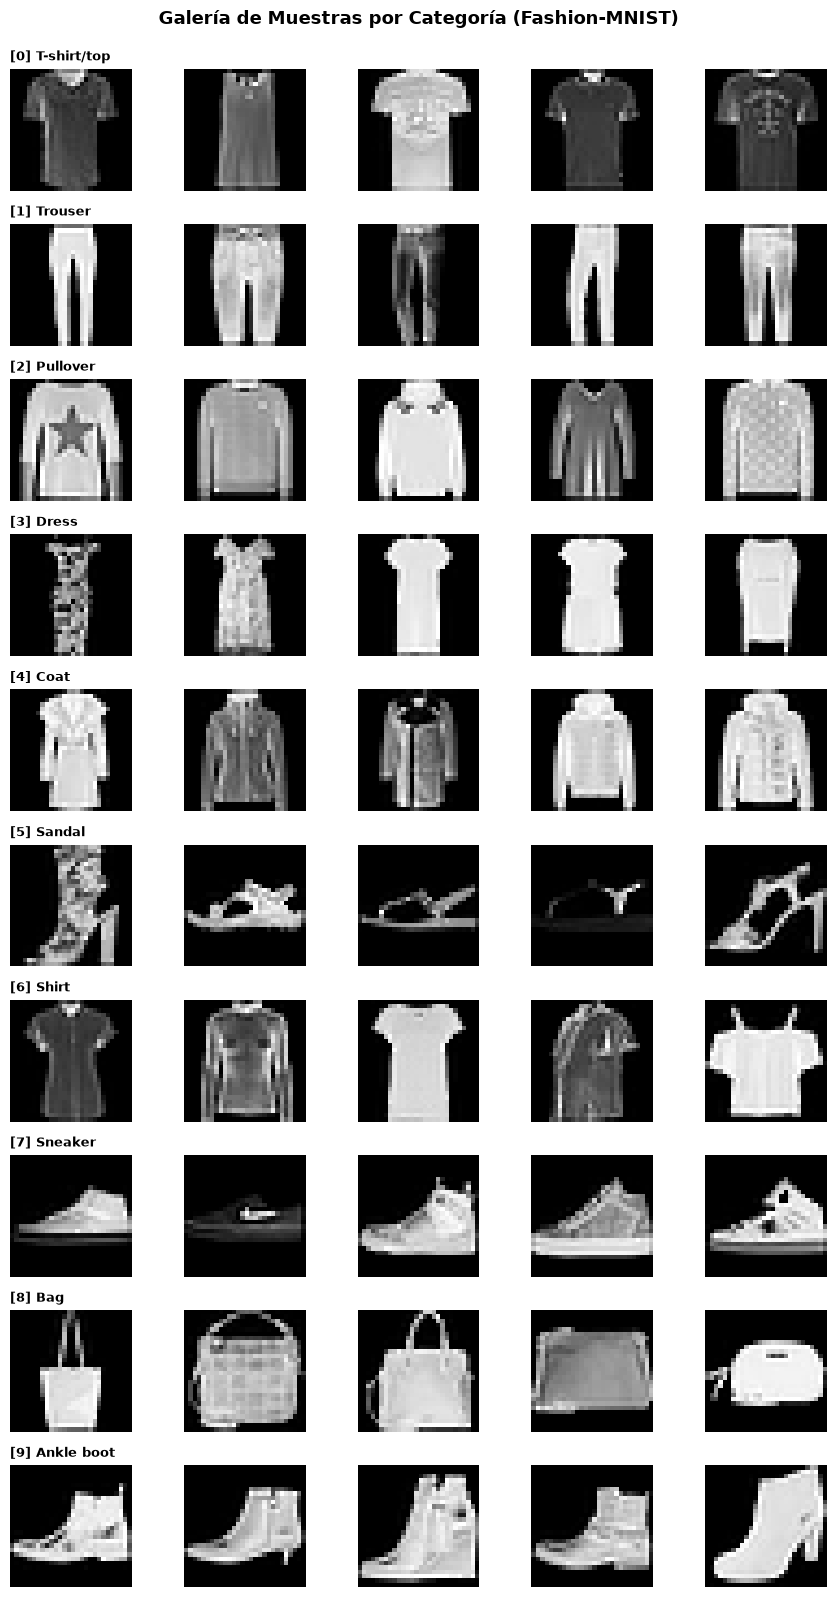

In [20]:
# 2.3.1 Galería de 5 muestras por clase para evaluar variabilidad intra-clase
np.random.seed(42)
n_samples = 5

fig, axes = plt.subplots(10, n_samples, figsize=(9, 16))
fig.suptitle("Galería de Muestras por Categoría (Fashion-MNIST)", fontsize=13, fontweight="bold", y=0.995)

for label_idx in range(10):
    class_indices = np.where(y_train_raw == label_idx)[0]
    chosen_indices = np.random.choice(class_indices, n_samples, replace=False)
    for col_idx, img_idx in enumerate(chosen_indices):
        ax = axes[label_idx, col_idx]
        ax.imshow(X_train_3d[img_idx], cmap="gray")
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(f"[{label_idx}] {labels_dict[label_idx]}", fontsize=9, loc="left", fontweight="semibold")

plt.tight_layout()
plt.show()


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


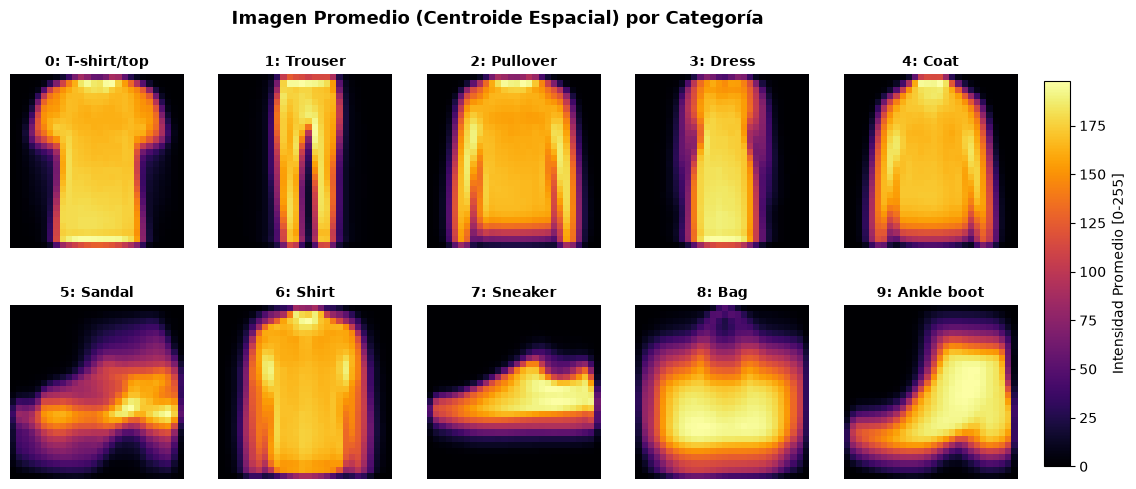

In [21]:
# 2.3.2 Cálculo y visualización de la Imagen Promedio (Mean Image) por clase
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
fig.suptitle("Imagen Promedio (Centroide Espacial) por Categoría", fontsize=13, fontweight="bold")

for label_idx in range(10):
    ax = axes[label_idx // 5, label_idx % 5]
    class_images = X_train_3d[y_train_raw == label_idx]
    mean_img = np.mean(class_images, axis=0)
    
    im = ax.imshow(mean_img, cmap="inferno")
    ax.set_title(f"{label_idx}: {labels_dict[label_idx]}", fontsize=10, fontweight="semibold")
    ax.axis("off")

# Barra de escala de intensidad promedio
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Intensidad Promedio [0-255]")
plt.subplots_adjust(right=0.9)
plt.show()


### 2.4 Estadísticas Descriptivas de Características (Intensidades de Píxel)

Cada imagen se compone de $28 \times 28 = 784$ píxeles, con intensidades discretas en $[0, 255]$.
A continuación se extraen las estadísticas agregadas globales de los píxeles y se grafica el histograma global de frecuencias para analizar la esparcidad (*sparsity*) y el contraste del dataset.


RESUMEN ESTADÍSTICO DE INTENSIDADES DE PÍXEL


,Métrica,Valor
0,Total de Píxeles Evaluados,"47,040,000"
1,Valor Mínimo,0
2,Primer Cuartil (Q1 - 25%),0.0
3,Mediana (Q2 - 50%),0.0
4,Media Global,72.94
5,Desviación Estándar (std),90.02
6,Tercer Cuartil (Q3 - 75%),163.0
7,Valor Máximo,255
8,Píxeles de Fondo Puro (Valor = 0),50.21%


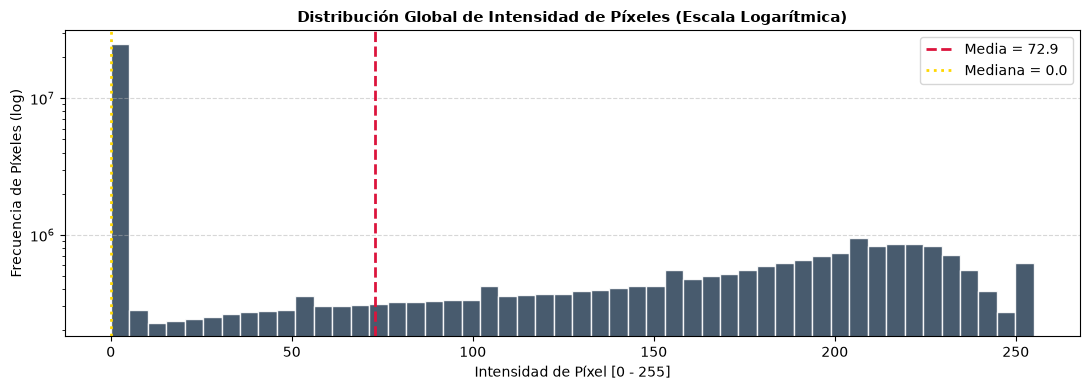

In [22]:
# 2.4 Estadísticas globales de píxeles e histograma
pixel_vals = X_train_2d.flatten()

stats_summary = pd.DataFrame({
    "Métrica": [
        "Total de Píxeles Evaluados",
        "Valor Mínimo",
        "Primer Cuartil (Q1 - 25%)",
        "Mediana (Q2 - 50%)",
        "Media Global",
        "Desviación Estándar (std)",
        "Tercer Cuartil (Q3 - 75%)",
        "Valor Máximo",
        "Píxeles de Fondo Puro (Valor = 0)"
    ],
    "Valor": [
        f"{len(pixel_vals):,}",
        f"{pixel_vals.min()}",
        f"{np.percentile(pixel_vals, 25):.1f}",
        f"{np.median(pixel_vals):.1f}",
        f"{pixel_vals.mean():.2f}",
        f"{pixel_vals.std():.2f}",
        f"{np.percentile(pixel_vals, 75):.1f}",
        f"{pixel_vals.max()}",
        f"{(pixel_vals == 0).sum() / len(pixel_vals) * 100:.2f}%"
    ]
})

print("=" * 60)
print("RESUMEN ESTADÍSTICO DE INTENSIDADES DE PÍXEL")
print("=" * 60)
display(stats_summary)

# Histograma de intensidad de píxeles
plt.figure(figsize=(11, 4))
plt.hist(pixel_vals, bins=50, color="#34495e", edgecolor="white", alpha=0.9, log=True)
plt.title("Distribución Global de Intensidad de Píxeles (Escala Logarítmica)", fontsize=11, fontweight="bold")
plt.xlabel("Intensidad de Píxel [0 - 255]", fontsize=10)
plt.ylabel("Frecuencia de Píxeles (log)", fontsize=10)
plt.axvline(pixel_vals.mean(), color="crimson", linestyle="--", linewidth=2, label=f"Media = {pixel_vals.mean():.1f}")
plt.axvline(np.median(pixel_vals), color="gold", linestyle=":", linewidth=2, label=f"Mediana = {np.median(pixel_vals):.1f}")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


### 2.5 Patrones Espaciales y Reducción de Dimensionalidad (PCA)

Para estudiar las correlaciones y la separabilidad de las características:
1. **Mapa de Varianza Espacial:** Calcula la desviación estándar de cada coordenada $(x, y)$ a lo largo de las 60,000 imágenes. Permite identificar las regiones espaciales informativas frente a las regiones de fondo redundante.
2. **Proyección 2D con PCA:** Reduce la dimensionalidad de 784 píxeles a las 2 componentes principales ($PC_1, PC_2$) para una muestra representativa de 5,000 imágenes, revelando cómo se agrupan naturalmente las diferentes categorías de prendas y calzado.


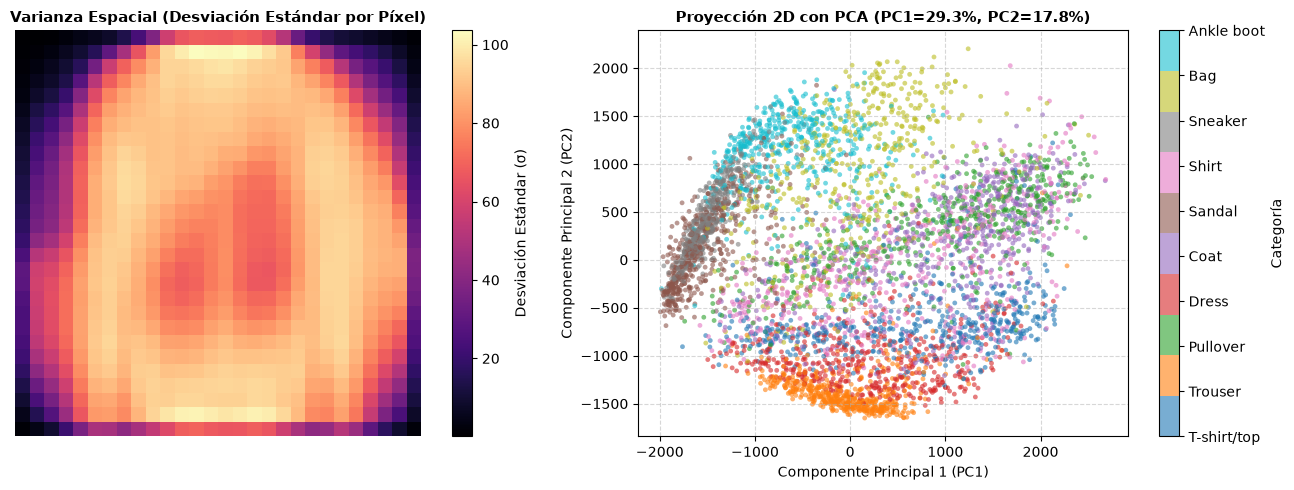

In [23]:
from sklearn.decomposition import PCA

# 1. Mapa espacial de varianza (desviación estándar por píxel)
pixel_std_spatial = np.std(X_train_3d, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im_std = axes[0].imshow(pixel_std_spatial, cmap="magma")
axes[0].set_title("Varianza Espacial (Desviación Estándar por Píxel)", fontsize=11, fontweight="bold")
axes[0].axis("off")
fig.colorbar(im_std, ax=axes[0], label="Desviación Estándar (σ)")

# 2. PCA 2D sobre una muestra representativa de 5,000 imágenes
np.random.seed(42)
sample_idx = np.random.choice(len(X_train_2d), size=5000, replace=False)
X_pca_sample = X_train_2d[sample_idx]
y_pca_sample = y_train_raw[sample_idx]

pca_model = PCA(n_components=2, random_state=42)
X_pca_2d = pca_model.fit_transform(X_pca_sample)
var_exp = pca_model.explained_variance_ratio_ * 100

cmap = plt.get_cmap("tab10", 10)
scatter = axes[1].scatter(
    X_pca_2d[:, 0], 
    X_pca_2d[:, 1], 
    c=y_pca_sample, 
    cmap=cmap, 
    alpha=0.6, 
    s=12, 
    edgecolors="none"
)

axes[1].set_title(f"Proyección 2D con PCA (PC1={var_exp[0]:.1f}%, PC2={var_exp[1]:.1f}%)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Componente Principal 1 (PC1)", fontsize=10)
axes[1].set_ylabel("Componente Principal 2 (PC2)", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.5)

cbar = fig.colorbar(scatter, ax=axes[1], ticks=range(10))
cbar.set_ticklabels(class_names)
cbar.set_label("Categoría")

plt.tight_layout()
plt.show()


### Conclusiones y Hallazgos Clave del EDA

A partir del análisis exploratorio realizado, se concluye:
1. **Integridad de Datos Óptima:** No existen valores nulos, registros corruptos ni píxeles fuera de rango. El 100% de las 70,000 imágenes es apto para modelado.
2. **Balance Perfecto:** Con exactamente 6,000 imágenes por clase en entrenamiento y 1,000 en prueba ($IR = 1.0$), el problema no presenta sesgo de frecuencia, validando el uso de métricas estándar como Exactitud (*Accuracy*) y macro F1-Score.
3. **Esparcidad y Geometría Central:** Cerca del 50% de los píxeles tienen valor 0 (fondo negro). Además, el mapa de varianza espacial confirma que el perímetro exterior de las imágenes posee varianza prácticamente nula, concentrándose la información en la ventana central.
4. **Separabilidad y Desafíos:** La proyección PCA revela que el calzado (*Sneaker*, *Sandal*, *Ankle boot*) y bolsos (*Bag*) forman agrupaciones bien diferenciadas, mientras que las prendas superiores (*T-shirt*, *Shirt*, *Pullover*, *Coat*) presentan notable solapamiento espacial. Estos pares serán los mayores causantes de confusión en los clasificadores supervisados.
5. **Necesidad de Normalización:** Debido a la dispersión de valores entre 0 y 255, es indispensable estandarizar las características (media 0, varianza 1) o escalar a $[0, 1]$ para garantizar la convergencia y equidad en la optimización de los modelos base.


# 3. Preparación de Datos e Ingeniería de Características

Creación de DataFrames estructurados y escalamiento de características.


In [24]:
feat_columns = ['pixel' + str(i) for i in range(X_train_2d.shape[1])]  #Create the feature columns (pixels from 0 to 784 -> 28x28)

In [25]:
df_train_fashion_mnist = pd.DataFrame(X_train_2d, columns=feat_columns)

df_train_fashion_mnist['label'] = y_train_raw

print('Size of the dataframe: {}'.format(df_train_fashion_mnist.shape))

print(df_train_fashion_mnist.head())

Size of the dataframe: (60000, 785)
   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       1       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0      33   
4       0       0       0       0       0       0       0       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...       114       130        76         0         0         0   
2      22  ...         0         1         0         0         0         0   
3      96  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783 

In [26]:
df_test_fashion_mnist = pd.DataFrame(X_test_2d, columns=feat_columns)

df_test_fashion_mnist['label'] = y_test_raw

print('Size of the dataframe: {}'.format(df_test_fashion_mnist.shape))

print(df_test_fashion_mnist.head())

Size of the dataframe: (10000, 785)
   pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       1   
3       0       0       0       0       0       0       0       0       0   
4       0       0       0       2       0       1       1       0       0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         3         0         3       174       189        67   
2       0  ...        58         0         0         0         0         0   
3      21  ...         0         0         0         0         0         0   
4       0  ...        12         0         0         0         0         0   

   pixel781  pixel782  pixel783 

**Scale the data**

In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
fashion_mnist_scaler = StandardScaler()

X_train = df_train_fashion_mnist.drop("label", axis = 1)
y_train = df_train_fashion_mnist['label']

X_test = df_test_fashion_mnist.drop("label", axis = 1)
y_test = df_test_fashion_mnist['label']

X_train = fashion_mnist_scaler.fit_transform(X_train)
X_test = fashion_mnist_scaler.transform(X_test)